# Dataset baseline: nvpdyf-bdd100k

Этот ноутбук покрывает следующие задачи:

1. Поиск и проверка датасета, а также разметки дня/ночи;
2. Базовая информация о датасете — количество объектов в разбивках, распределение по классам, распределение по дню/ночи, проверки качества данных (пропущенные/пустые/«осиротевшие» разметки);
3. Отрисовка нескольких сцен с рамками ground-truth для визуальной проверки перед тем, как на этих данных начнётся обучение — произвольная пара, и отдельно явная пара день/ночь.

Вся основная логика находится в [`src/datasets/nvpdyf_bdd100k.py`](src/datasets/nvpdyf_bdd100k.py)
и [`src/utils/visualize.py`](src/utils/visualize.py) - этот ноутбук просто вызывает ее и показывает результаты.


In [1]:
import logging
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from src.datasets import nvpdyf_bdd100k as ds
from src.utils.visualize import draw_ground_truth

# проект обычно логгирует через Hydra (см. train.py); здесь мы хотим, чтобы
# logger.info(...) просто печатался в консоль
logging.basicConfig(level=logging.INFO, format="%(message)s")


c:\Users\Георгий\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Поиск датасета

Указывайте `input_dir` на корень монтирования, а не на конкретную
подпапку датасета — точный путь в Kaggle может отличаться, а поиск ниже
рекурсивный, поэтому он найдёт датасет в любом случае.

- В Kaggle: `/kaggle/input` (значение по умолчанию ниже).
- Локально: переопределите `INPUT_DIR` на папку, куда вы загрузили
  `nvpdyf-bdd100k`, или укажите значение по умолчанию из
  `src/configs/datasets/nvpdyf_bdd100k.yaml`.


In [4]:
# Значение input_dir по умолчанию, взятое из конфига Hydra, который использует train.py
_cfg = OmegaConf.load("src/configs/datasets/nvpdyf_bdd100k.yaml")

INPUT_DIR = Path("/kaggle/input")  # <- переопределите для локального запуска
if not INPUT_DIR.exists():
    INPUT_DIR = Path(_cfg.input_dir)

DATA_ROOT = ds.find_dataset_root(INPUT_DIR)
CLASSES = ds.load_classes(DATA_ROOT)

print(f"dataset root: {DATA_ROOT}")
print(f"classes ({len(CLASSES)}): {CLASSES}")


dataset root: data\nvpdyf_bdd100k
classes (7): {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorcycle', 4: 'person', 5: 'traffic light', 6: 'truck'}


### Разметка дня/ночи (timeofday.csv)

`find_timeofday_csv` ищет его так же
рекурсивно, как `find_dataset_root` ищет `data.yaml`. Если файла ещё
нет — всё остальное всё равно работает, просто разделы про день/ночь
ниже будут пустыми.


In [5]:
            TOD_CSV = ds.find_timeofday_csv(INPUT_DIR)
            TOD = ds.load_timeofday(TOD_CSV) if TOD_CSV else {}

            if TOD_CSV:
                print(f"timeofday.csv: {TOD_CSV} ({len(TOD)} rows)")
            else:
                print("timeofday.csv not found under INPUT_DIR - day/night sections below will be empty")


timeofday.csv: data\nvpdyf_bdd100k\timeofday.csv (55110 rows)


## 2. Информация о датасете

Количество кадров и рамок по разбивкам, а также несколько проверок качества,
о которых полезно знать *до* начала обучения:

- **missing_labels** — изображения без соответствующего `.txt`-файла
  (Ultralytics считает их неразмеченными, а не пустыми — это отличается от
  намеренного кадра «без объектов»);
- **empty_labels** — `.txt`-файлы с нулевым количеством строк (кадр без объектов,
  например, пустая дорога — допустимо, но полезно знать количество);
- **orphan_labels** — `.txt`-файлы без соответствующего изображения (мёртвый груз,
  обычно признак проблемы упаковки датасета);
- изображения без строки в `timeofday.csv` попадают в `unknown` в разбивке
  по дню/ночи ниже — по той же причине: полезно знать, сколько их, прежде
  чем доверять итоговому распределению день/ночь.




In [6]:
SPLITS = [s for s in ("train", "val", "test") if (DATA_ROOT / "images" / s).is_dir()]

stats = {split: ds.collect_stats(DATA_ROOT, split, tod_map=TOD) for split in SPLITS}
ds.describe_dataset(stats, CLASSES)


train:  36709 images  missing_labels=0    empty_labels=108  orphan_labels=0    boxes= 575010
val  :   9214 images  missing_labels=0    empty_labels=36   orphan_labels=0    boxes= 143676
test :   9187 images  missing_labels=0    empty_labels=38   orphan_labels=0    boxes= 138009
objects/image (all splits): avg=15.55 median=15 min=0 max=74
class             boxes  train  val  test
car              579280  388900  96620  93760
traffic light    140902  92755  23407  24740
person            88570  60368  15390  12812
truck             27939  19260  4807  3872
bus               10594   7309  1827  1458
bicycle            6655   4541  1172   942
motorcycle         2755   1877  453   425
class imbalance (max/min): 210.3x


### Распределение по классам

Один столбец на класс, суммированный по всем разбивкам, отсортированный по убыванию.


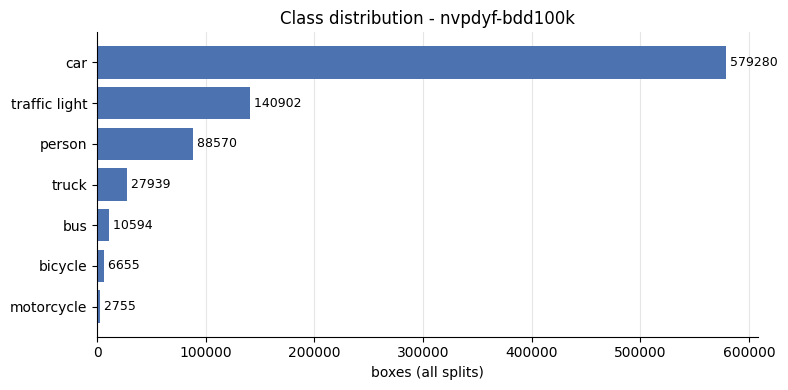

In [7]:
total_counts = Counter()
for s in stats.values():
    total_counts.update(s["class_counts"])

# Включаем каждый класс из data.yaml, даже если у него 0 рамок — класс,
# полностью отсутствующий в датасете, легко не заметить, если он просто пропадёт
# из графика, а столбец нулевой длины для него будет заметен.
items = sorted(
    ((cid, total_counts[cid]) for cid in CLASSES), key=lambda kv: kv[1]
)  # ascending, for barh
labels = [CLASSES[cid] for cid, _ in items]
values = [v for _, v in items]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, values, color="#4C72B0")
ax.set_xlabel("boxes (all splits)")
ax.set_title("Class distribution - nvpdyf-bdd100k")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="0.9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for bar, v in zip(bars, values):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f" {v}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### Распределение по дню и ночи

По `dataset/prepare_bdd100k_nvpd.py` (скрипт, которым собирали датасет —
см. ветки `master`/`model-benchmark`), `train`/`val` сэмплированы с точным
соотношением **день:ночь = 4:1**, а `test` — это исходная validation-разбивка
BDD100K как есть, без балансировки. Цифры ниже должны примерно этому
соответствовать, с поправкой на то, что покажет `unknown`.


In [8]:
ds.describe_daynight(stats, CLASSES)


train: {'daytime': 29365, 'night': 7344}
val  : {'daytime': 7354, 'night': 1860}
test : {'daytime': 5258, 'night': 3929}
class             night      day night share   (all splits)
car              120271   459009       20.8%
traffic light     39202   101700       27.8%
person             9345    79225       10.6%
truck              2494    25445        8.9%
bus                1030     9564        9.7%
bicycle             699     5956       10.5%
motorcycle          311     2444       11.3%


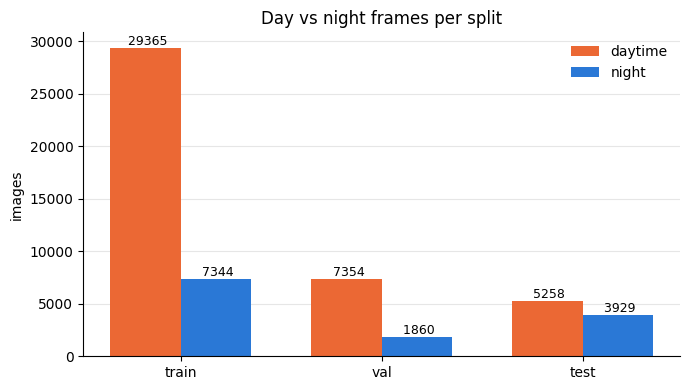

In [9]:
tods = ["daytime", "night"]
tod_colors = {"daytime": "#eb6834", "night": "#2a78d6"}  # тёплый = день, холодный = ночь

x = np.arange(len(SPLITS))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, tod in enumerate(tods):
    counts = [stats[s]["n_images_by_tod"].get(tod, 0) for s in SPLITS]
    bars = ax.bar(x + (i - 0.5) * width, counts, width, label=tod, color=tod_colors[tod])
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f" {v}",
                 ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(SPLITS)
ax.set_ylabel("images")
ax.set_title("Day vs night frames per split")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="0.9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Размер и форма боксов

Пороги «small/medium/large» — канонические COCO:
`<32x32px` / `32x32-96x96px` / `>96x96px`, переведённые в долю площади
кадра через реальный размер кадра (`IMG_W x IMG_H` = `1280x720`), а не
на глаз — рамки в датасете нормализованы, а не в пикселях.


In [10]:
ds.describe_box_geometry(stats)


box size (all): small(<32x32px)=50.6%  medium(32x32-96x96px)=34.2%  large(>96x96px)=15.2%
aspect ratio w/h (all): median=0.61  p5=0.20  p95=1.29
box size by time of day:
  daytime  n=683343  small= 50.5%  medium= 34.3%  large= 15.2%  median_area=0.108%
  night    n=173352  small= 50.7%  medium= 34.1%  large= 15.2%  median_area=0.107%


Числа выше — это три корзины. Полное распределение размеров нагляднее
смотрится гистограммой, отдельно для дня и для ночи (по оси Y —
плотность, а не количество: ночных кадров меньше, чем дневных, и без
нормировки гистограммы было бы не сравнить форму распределений, только
масштаб).


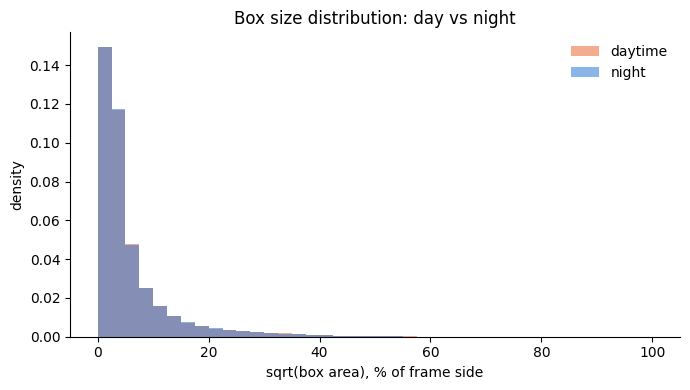

In [11]:
by_tod = ds.box_areas_by_timeofday(stats)
tod_colors = {"daytime": "#eb6834", "night": "#2a78d6"}

fig, ax = plt.subplots(figsize=(7, 4))
for tod in ("daytime", "night"):
    areas = by_tod.get(tod)
    if not areas:
        continue
    sizes = np.sqrt(areas) * 100  # sqrt(area) как % стороны кадра - легче читать, чем сырую площадь
    ax.hist(sizes, bins=40, range=(0, 100), density=True, alpha=0.55,
            color=tod_colors[tod], label=tod)

ax.set_xlabel("sqrt(box area), % of frame side")
ax.set_ylabel("density")
ax.set_title("Box size distribution: day vs night")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Разрешение кадров

Дешёвая проверка качества данных: весь датасет ожидается в едином
разрешении `1280x720` (нативный размер кадра BDD100K).


In [12]:
res_counts = ds.check_resolutions(DATA_ROOT, SPLITS)
ds.describe_resolutions(res_counts)


resolutions (2000 sampled):
  1280x720: 2000 (100.0%)


## 3. Несколько сцен

Два случайных кадра (один из `train`, один из `val`) с нанесёнными
рамками ground-truth.


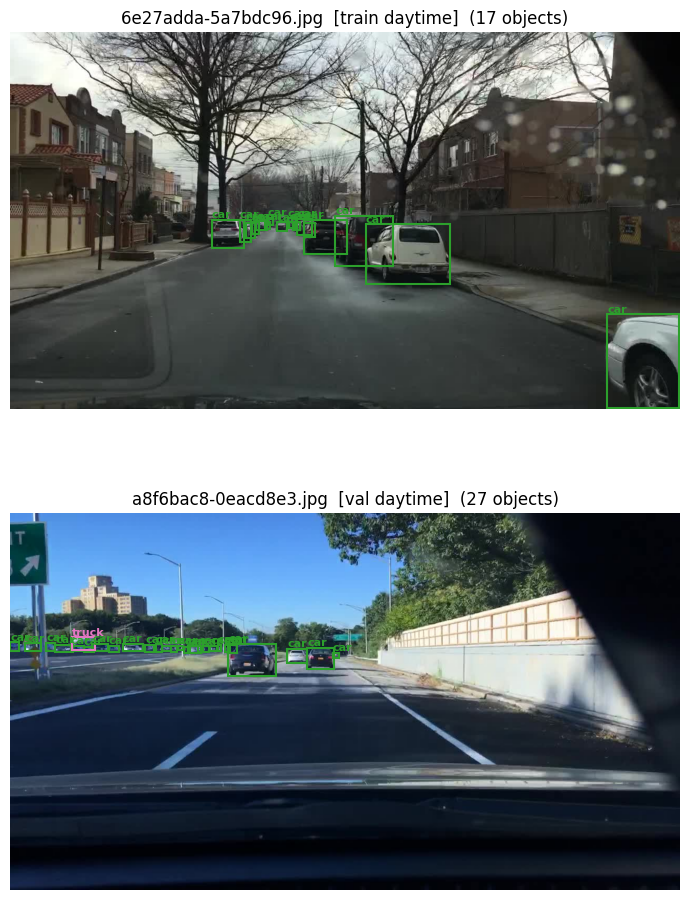

In [13]:
SEED = _cfg.sample_seed

scenes = []
for split in ("train", "val"):
    if split in SPLITS:
        scenes += ds.sample_scenes(DATA_ROOT, [split], n=1, seed=SEED, tod_map=TOD)

fig = draw_ground_truth(scenes, CLASSES)


### День и ночь рядом

Поиск идёт сразу по всем разбивкам
(`SPLITS`, а не по одной), потому что ночных кадров в `train`/`val` по
построению меньшинство (см. соотношение 4:1 выше), и в случайной выборке
одной-единственной разбивки они могут просто не попасться.


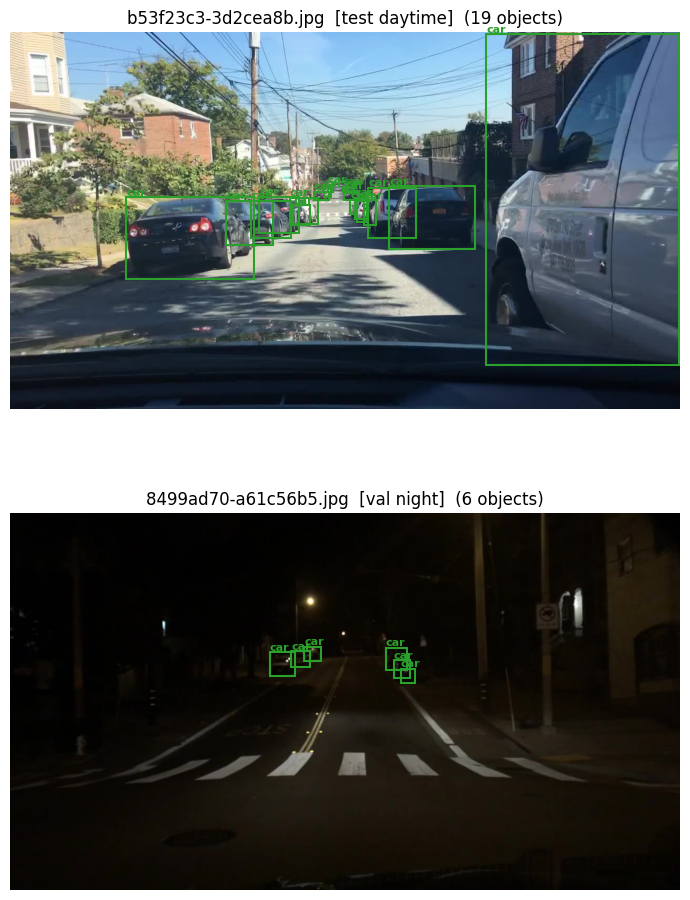

In [14]:
if TOD:
    day_night_scenes = ds.sample_scenes(DATA_ROOT, SPLITS, n=1, seed=SEED, tod="daytime", tod_map=TOD)
    day_night_scenes += ds.sample_scenes(DATA_ROOT, SPLITS, n=1, seed=SEED, tod="night", tod_map=TOD)
    fig = draw_ground_truth(day_night_scenes, CLASSES)
else:
    print("no timeofday.csv - skipping the day/night scene pair")
